In [103]:
symbol = 'TQQQ'

import yfinance
hist = yfinance.download(tickers=symbol,period="7d",interval="1m")

[*********************100%***********************]  1 of 1 completed


In [104]:
# change column name to lower case and without space.
# option 1
new_col_list = []
for i in hist.columns:
    new_col_list.append(i.lower().replace(" ", ""))
hist.columns = new_col_list

In [105]:
# option 2 
# dataframe.columns.values == array
# dataframe.columns == index
# pandas does not want pd.Indexs to be mutable
for i,j in enumerate(hist.columns):
    hist.columns.values[i] = j.lower().replace(" ", "")


In [106]:
hist

,open,high,low,close,adjclose,volume
Datetime,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838
...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636


In [107]:
hist['close'].rolling(20).mean()

Datetime
2023-03-10 09:30:00-05:00          NaN
2023-03-10 09:31:00-05:00          NaN
2023-03-10 09:32:00-05:00          NaN
2023-03-10 09:33:00-05:00          NaN
2023-03-10 09:34:00-05:00          NaN
                               ...    
2023-03-20 15:55:00-04:00    24.767580
2023-03-20 15:56:00-04:00    24.771850
2023-03-20 15:57:00-04:00    24.778850
2023-03-20 15:58:00-04:00    24.783855
2023-03-20 15:59:00-04:00    24.789815
Name: close, Length: 2728, dtype: float64

In [108]:
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt

def get_bollinger_bands(data, rate=20):
    sma = data['close'].rolling(rate).mean()
    std = data['close'].rolling(rate).std()
    bollinger_up = pd.Series(sma + std * 2, name = 'bollinger_up_' + str(rate)) # Calculate top band
    bollinger_down = pd.Series(sma - std * 2, name ='bollinger_down_' + str(rate)) # Calculate bottom band
    data = data.join([bollinger_up,bollinger_down])
    return data

# symbol = 'AAPL'
# df = pdr.DataReader(symbol, 'yahoo', '2014-07-01', '2015-07-01')
# df.index = np.arange(df.shape[0])




In [109]:
def SMA(data, ndays=20): 
    SMA = pd.Series(data['close'].rolling(ndays).mean(), name = 'SMA_'+ str(ndays)) 
    data = data.join(SMA) 
    return data

In [110]:
def EWMA(data, ndays=20): 
    EMA = pd.Series(data['close'].ewm(span = ndays, min_periods = ndays - 1).mean(), 
                 name = 'EWMA_' + str(ndays)) 
    data = data.join(EMA) 
    return data

In [111]:
def rsi(data, periods = 20):
    
    close_delta = data['close'].diff()

    # Make two series: one for lower closes and one for higher closes
    up = close_delta.clip(lower=0)
    down = -1 * close_delta.clip(upper=0)
    
    ma_up = up.ewm(com = periods - 1, adjust=True, min_periods = periods).mean()
    ma_down = down.ewm(com = periods - 1, adjust=True, min_periods = periods).mean()

    rsi = ma_up / ma_down
    rsi = 100 - (100/(1 + rsi))
    RSI = pd.Series(rsi, name='RSI_' + str(periods))
    data = data.join(RSI)
    return data

In [112]:
def gain(x):
    return ((x > 0) * x).sum()


def loss(x):
    return ((x < 0) * x).sum()


# Calculate money flow index
def mfi(data, n=20):
    high = data['high']
    low = data['low']
    close = data['close']
    volume = data['volume']
    typical_price = (high + low + close)/3
    money_flow = typical_price * volume
    mf_sign = np.where(typical_price > typical_price.shift(1), 1, -1)
    signed_mf = money_flow * mf_sign
    mf_avg_gain = signed_mf.rolling(n).apply(gain, raw=True)
    mf_avg_loss = signed_mf.rolling(n).apply(loss, raw=True)
    mfi = (100 - (100 / (1 + (mf_avg_gain / abs(mf_avg_loss)))))
    MFI = pd.Series(mfi, name='MFI_' + str(n))
    data = data.join(MFI)
    return data

In [113]:
def percent_change(data, level = 'close'):
    PER = pd.Series((data[level] - data[level].shift(1))/data[level].shift(1)*100, name = 'PER_'+level)
    data = data.join(PER)
    return data
    

In [114]:
hist = mfi(hist,14)

In [115]:
hist

,open,high,low,close,adjclose,volume,MFI_14
Datetime,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN
...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366


In [116]:
hist = rsi(hist, 14)

In [117]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14
Datetime,,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN,NaN
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN,NaN
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN,NaN
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN,NaN
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN,NaN
...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706


In [118]:
hist = get_bollinger_bands(hist, 14)

In [119]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14
Datetime,,,,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN,NaN,NaN,NaN
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN,NaN,NaN,NaN
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN,NaN,NaN,NaN
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN,NaN,NaN,NaN
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382


In [120]:
hist = percent_change(hist, 'close')

In [121]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close
Datetime,,,,,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN,NaN,NaN,NaN,NaN
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN,NaN,NaN,NaN,-0.045182
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN,NaN,NaN,NaN,0.461256
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN,NaN,NaN,NaN,-0.603766
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN,NaN,NaN,NaN,-0.635610
...,...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224,-0.158807
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351,0.100124
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382,0.058877


In [122]:
hist = percent_change(hist, 'volume')

In [123]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN,NaN,NaN,NaN,-0.045182,-96.133449
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN,NaN,NaN,NaN,0.461256,34.556404
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN,NaN,NaN,NaN,-0.603766,-16.913417
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN,NaN,NaN,NaN,-0.635610,3.007712
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224,-0.158807,-5.464176
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351,0.100124,-45.837085
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382,0.058877,-7.693651


2023-03-10


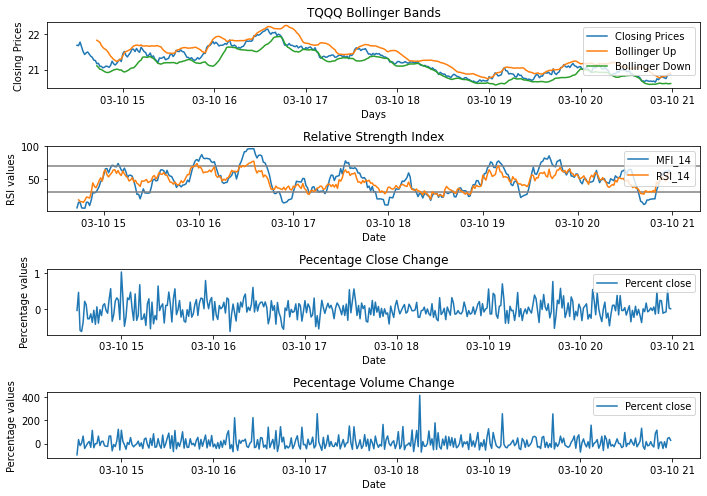

2023-03-13


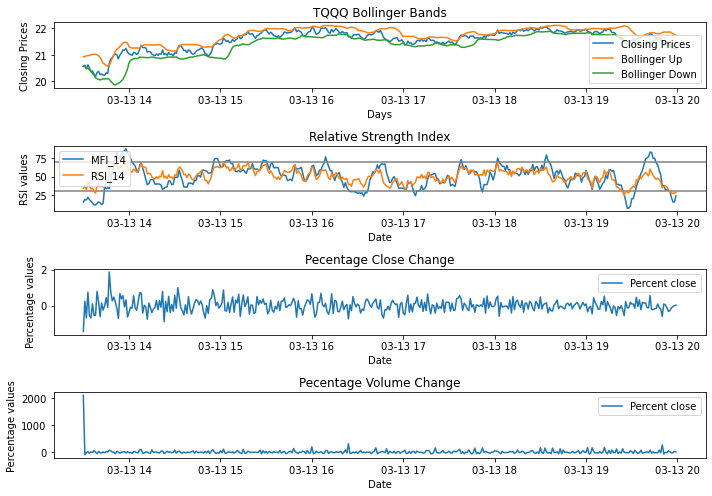

2023-03-14


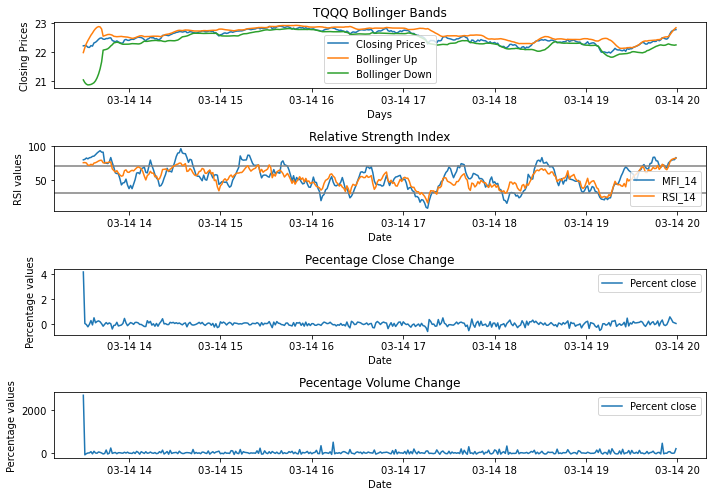

2023-03-15


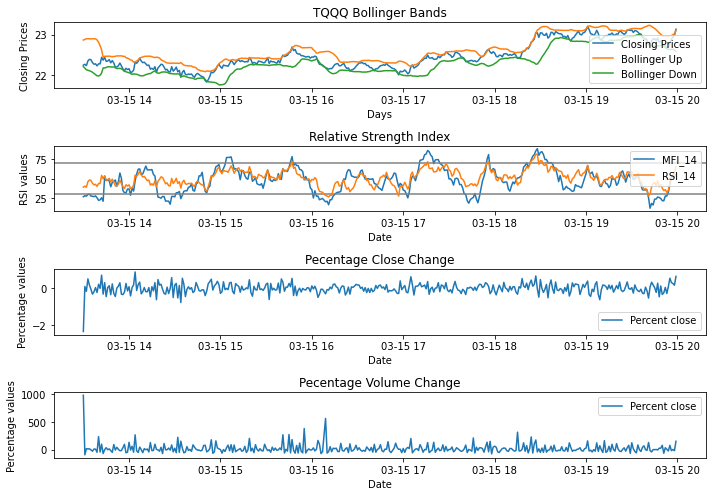

2023-03-16


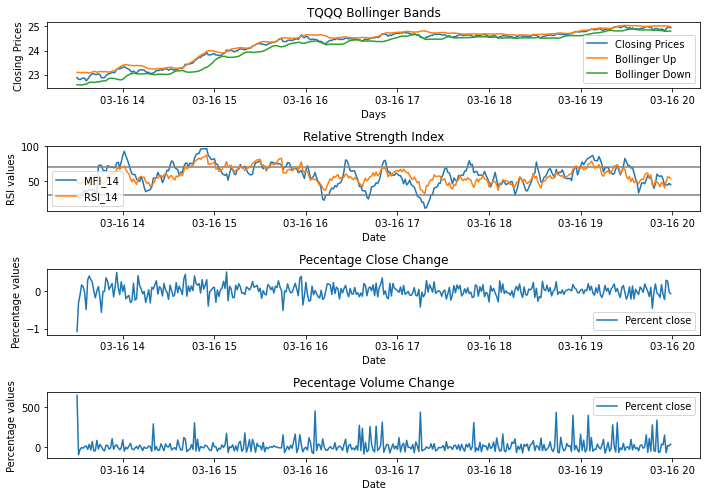

2023-03-17


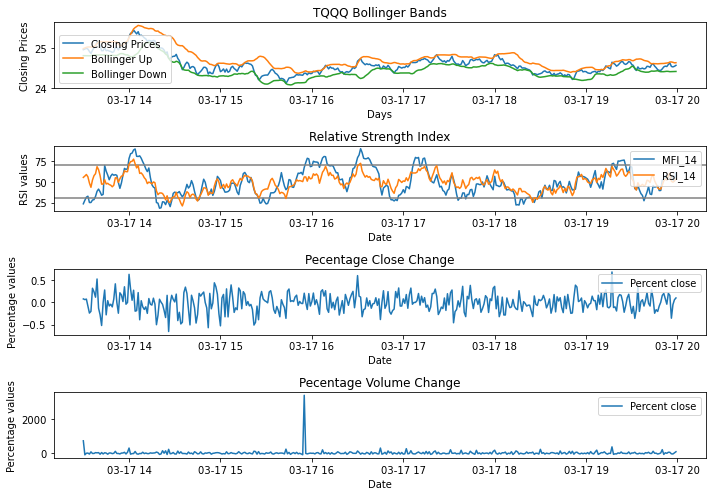

2023-03-20


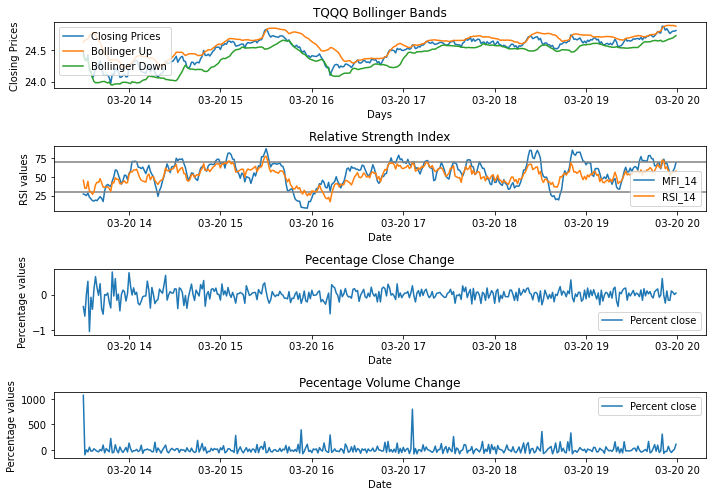

In [83]:
for i in np.unique(hist.index.date):
    print(i)
    sub_hist = hist[str(i):str(i)]

    
    fig = plt.figure(figsize=(10, 7))

    # Define position of 1st subplot
    ax = fig.add_subplot(4, 1, 1)

    # Set the title and axis labels
    plt.title(symbol + ' Bollinger Bands')
    plt.xlabel('Days')
    plt.ylabel('Closing Prices')
    plt.plot(sub_hist['close'], label='Closing Prices')
    plt.plot(sub_hist['bollinger_up_14'], label='Bollinger Up')
    plt.plot(sub_hist['bollinger_down_14'], label='Bollinger Down')
    plt.legend()

    # Define position of 2nd subplot
    bx = fig.add_subplot(4, 1, 2)

    # Set the title and axis labels
    plt.title('Relative Strength Index')
    plt.xlabel('Date')
    plt.ylabel('RSI values')
    
    plt.plot(sub_hist['MFI_14'], label='MFI_14')
    plt.axhline(y=30, color='grey', linestyle='-')
    plt.axhline(y=70, color='grey', linestyle='-')
    plt.plot(sub_hist['RSI_14'], label='RSI_14') 

    # Add a legend to the axis
    plt.legend()

    
    
    cx = fig.add_subplot(4, 1, 3)
    plt.title('Pecentage Close Change')
    plt.xlabel('Date')
    plt.ylabel('Percentage values')
    
    plt.plot(sub_hist['PER_close'], label='Percent close')

    plt.legend()
    

    cx = fig.add_subplot(4, 1, 4)
    plt.title('Pecentage Volume Change')
    plt.xlabel('Date')
    plt.ylabel('Percentage values')
    
    plt.plot(sub_hist['PER_volume'], label='Percent close')

    plt.legend()
    
    
    plt.tight_layout()
    plt.show()
    
    
   

In [84]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,under_BBL
Datetime,,,,,,,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN,NaN,NaN,NaN,NaN,NaN,0
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN,NaN,NaN,NaN,-0.045182,-96.133449,0
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN,NaN,NaN,NaN,0.461256,34.556404,0
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN,NaN,NaN,NaN,-0.603766,-16.913417,0
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN,NaN,NaN,NaN,-0.635610,3.007712,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224,-0.158807,-5.464176,0
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351,0.100124,-45.837085,0
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382,0.058877,-7.693651,0


In [85]:
for i in np.unique(hist.index.date):
    print(i)
    sub_hist = hist[str(i):str(i)]

    for i in range(5):
        sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
    sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
    sub_hist['success'] = np.where(sub_hist['close']*1.001 < sub_hist['highest'], 1,0) # 0.1%
    print(sub_hist)

2023-03-10
                                open       high        low      close  \
Datetime                                                                
2023-03-10 09:30:00-05:00  21.820000  21.830000  21.650000  21.689800   
2023-03-10 09:31:00-05:00  21.690001  21.709999  21.580000  21.680000   
2023-03-10 09:32:00-05:00  21.680099  21.850000  21.660000  21.780001   
2023-03-10 09:33:00-05:00  21.780001  21.869900  21.610001  21.648500   
2023-03-10 09:34:00-05:00  21.630501  21.679899  21.510000  21.510900   
...                              ...        ...        ...        ...   
2023-03-10 15:55:00-05:00  20.780001  20.780001  20.730000  20.764400   
2023-03-10 15:56:00-05:00  20.760000  20.770000  20.730000  20.747000   
2023-03-10 15:57:00-05:00  20.740101  20.858900  20.740101  20.856001   
2023-03-10 15:58:00-05:00  20.850100  20.870001  20.830000  20.860001   
2023-03-10 15:59:00-05:00  20.860001  20.870001  20.809999  20.860001   

                            adjclose   

<ipython-input-85-8bdf5fd8dc6a>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
<ipython-input-85-8bdf5fd8dc6a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-85-8bdf5fd8dc6a>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [25]:
sub_hist.dropna(axis=0,inplace=True)

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [26]:
X_df = sub_hist[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume']]
y_df = sub_hist['success']

In [27]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,
2023-03-20 09:30:00-04:00,24.487600,11924547,27.216980,45.354119,24.636237,24.411863,-0.335366,1068.173055
2023-03-20 09:31:00-04:00,24.339899,1184673,26.205860,34.820236,24.661899,24.369045,-0.603168,-90.065258
2023-03-20 09:32:00-04:00,24.340000,1251200,25.096826,34.831392,24.678453,24.338204,0.000415,5.615642
2023-03-20 09:33:00-04:00,24.429800,828817,28.287770,44.000779,24.679116,24.335941,0.368940,-33.758232
2023-03-20 09:34:00-04:00,24.178499,1313494,22.907784,30.898601,24.732006,24.239980,-1.028665,58.478168
...,...,...,...,...,...,...,...,...
2023-03-20 15:50:00-04:00,24.889999,1323109,68.223765,72.492637,24.857920,24.642308,0.443499,314.009775
2023-03-20 15:51:00-04:00,24.884501,483105,73.579945,71.421895,24.884569,24.646302,-0.022093,-63.487135
2023-03-20 15:52:00-04:00,24.825001,372151,67.896794,60.934258,24.892166,24.655148,-0.239104,-22.966850


In [28]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.3,
                                  random_state=1)

In [30]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [31]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.500000
1  KNN  0.603595
2  SVC  0.500000
3  GNB  0.482680
4   RF  0.814052
5   GB  0.781373


In [32]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.468750
1  KNN  0.598958
2  SVC  0.468750
3  GNB  0.505208
4   RF  0.817708
5   GB  0.781250


In [33]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.810 (0.043)


In [34]:
n_scores

array([0.83333333, 0.8       , 0.77777778, 0.79775281, 0.80898876,
       0.76666667, 0.75555556, 0.9       , 0.80898876, 0.84269663,
       0.81111111, 0.75555556, 0.76666667, 0.83146067, 0.88764045])

In [35]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\hkim\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [36]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.8072916666666666

In [86]:
sub_hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,under_BBL,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,,
2023-03-20 09:30:00-04:00,24.430000,24.490000,24.389999,24.487600,24.487600,11924547,27.216980,45.354119,24.636237,24.411863,-0.335366,1068.173055,0,24.480000,24.389999,24.440001,24.450001,24.219999,24.480000,0
2023-03-20 09:31:00-04:00,24.480000,24.480000,24.264999,24.339899,24.339899,1184673,26.205860,34.820236,24.661899,24.369045,-0.603168,-90.065258,1,24.389999,24.440001,24.450001,24.219999,24.179899,24.450001,1
2023-03-20 09:32:00-04:00,24.330000,24.389999,24.280001,24.340000,24.340000,1251200,25.096826,34.831392,24.678453,24.338204,0.000415,5.615642,0,24.440001,24.450001,24.219999,24.179899,24.129999,24.450001,1
2023-03-20 09:33:00-04:00,24.349199,24.440001,24.323400,24.429800,24.429800,828817,28.287770,44.000779,24.679116,24.335941,0.368940,-33.758232,0,24.450001,24.219999,24.179899,24.129999,24.250000,24.450001,0
2023-03-20 09:34:00-04:00,24.430000,24.450001,24.170000,24.178499,24.178499,1313494,22.907784,30.898601,24.732006,24.239980,-1.028665,58.478168,1,24.219999,24.179899,24.129999,24.250000,24.330000,24.330000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224,-0.158807,-5.464176,0,24.820000,24.820000,24.819901,24.825399,NaN,24.825399,1
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351,0.100124,-45.837085,0,24.820000,24.819901,24.825399,NaN,NaN,24.825399,1
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382,0.058877,-7.693651,0,24.819901,24.825399,NaN,NaN,NaN,24.825399,0


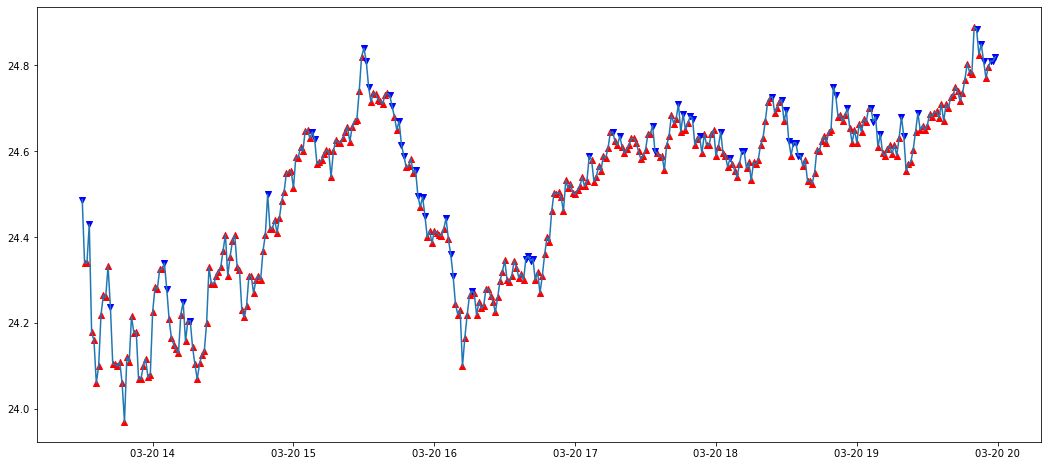

In [87]:
plt.figure(figsize=(18,8))
plt.plot(sub_hist['close'], label='Closing Prices')
plt.scatter(sub_hist[sub_hist['success']==1]['close'].index, sub_hist[sub_hist['success']==1]['close'],label='success', marker = '^', color = 'r')
plt.scatter(sub_hist[sub_hist['success']==0]['close'].index, sub_hist[sub_hist['success']==0]['close'],label='fail', marker = 'v', color = 'b')


In [88]:
sub_hist[sub_hist['success']==0]['close'].index

DatetimeIndex(['2023-03-20 09:30:00-04:00', '2023-03-20 09:33:00-04:00',
               '2023-03-20 09:42:00-04:00', '2023-03-20 10:05:00-04:00',
               '2023-03-20 10:06:00-04:00', '2023-03-20 10:13:00-04:00',
               '2023-03-20 10:16:00-04:00', '2023-03-20 10:49:00-04:00',
               '2023-03-20 11:08:00-04:00', '2023-03-20 11:09:00-04:00',
               '2023-03-20 11:30:00-04:00', '2023-03-20 11:31:00-04:00',
               '2023-03-20 11:32:00-04:00', '2023-03-20 11:41:00-04:00',
               '2023-03-20 11:42:00-04:00', '2023-03-20 11:45:00-04:00',
               '2023-03-20 11:46:00-04:00', '2023-03-20 11:47:00-04:00',
               '2023-03-20 11:52:00-04:00', '2023-03-20 11:53:00-04:00',
               '2023-03-20 11:55:00-04:00', '2023-03-20 11:56:00-04:00',
               '2023-03-20 12:05:00-04:00', '2023-03-20 12:07:00-04:00',
               '2023-03-20 12:08:00-04:00', '2023-03-20 12:16:00-04:00',
               '2023-03-20 12:39:00-04:00', '2023-0

In [89]:
sub_hist.groupby(by = 'success').count()

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,under_BBL,high_0,high_1,high_2,high_3,high_4,highest
success,,,,,,,,,,,,,,,,,,,
0,68,68,68,68,68,68,68,68,68,68,68,68,68,67,66,65,65,65,67
1,322,322,322,322,322,322,322,322,322,322,322,322,322,322,322,322,321,320,322


In [90]:
len(sub_hist[sub_hist['success']==1])/len(sub_hist['success'])

0.8256410256410256

In [77]:
len(sub_hist['success']), len(sub_hist[sub_hist['success']==1])

(390, 10)

In [68]:
sub_hist.groupby(by = 'success').mean()

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest
success,,,,,,,,,,,,,,,,,,
0,24.592819,24.623669,24.563703,24.595531,24.595531,547552.882353,55.812304,53.293139,24.684653,24.479890,0.006009,49.159835,24.600725,24.566232,24.551266,24.541183,24.535661,24.603313
1,24.484627,24.517002,24.452719,24.485128,24.485128,388559.819876,54.304643,51.601954,24.591849,24.373207,0.002057,13.380914,24.522191,24.529636,24.533204,24.535536,24.536925,24.571004


In [69]:
sub_hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,
2023-03-20 09:30:00-04:00,24.430000,24.490000,24.389999,24.487600,24.487600,11924547,27.216980,45.354119,24.636237,24.411863,-0.335366,1068.173055,24.480000,24.389999,24.440001,24.450001,24.219999,24.480000,0
2023-03-20 09:31:00-04:00,24.480000,24.480000,24.264999,24.339899,24.339899,1184673,26.205860,34.820236,24.661899,24.369045,-0.603168,-90.065258,24.389999,24.440001,24.450001,24.219999,24.179899,24.450001,1
2023-03-20 09:32:00-04:00,24.330000,24.389999,24.280001,24.340000,24.340000,1251200,25.096826,34.831392,24.678453,24.338204,0.000415,5.615642,24.440001,24.450001,24.219999,24.179899,24.129999,24.450001,1
2023-03-20 09:33:00-04:00,24.349199,24.440001,24.323400,24.429800,24.429800,828817,28.287770,44.000779,24.679116,24.335941,0.368940,-33.758232,24.450001,24.219999,24.179899,24.129999,24.250000,24.450001,0
2023-03-20 09:34:00-04:00,24.430000,24.450001,24.170000,24.178499,24.178499,1313494,22.907784,30.898601,24.732006,24.239980,-1.028665,58.478168,24.219999,24.179899,24.129999,24.250000,24.330000,24.330000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224,-0.158807,-5.464176,24.820000,24.820000,24.819901,24.825399,NaN,24.825399,1
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351,0.100124,-45.837085,24.820000,24.819901,24.825399,NaN,NaN,24.825399,1
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382,0.058877,-7.693651,24.819901,24.825399,NaN,NaN,NaN,24.825399,0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFECV

from imblearn.over_sampling import SMOTE

## last day data, resampling, 

In [25]:
sub_hist.dropna(axis=0,inplace=True)

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [26]:
X_df = sub_hist[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume']]
y_df = sub_hist['success']

In [27]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,
2023-03-20 09:30:00-04:00,24.487600,11924547,27.216980,45.354119,24.636237,24.411863,-0.335366,1068.173055
2023-03-20 09:31:00-04:00,24.339899,1184673,26.205860,34.820236,24.661899,24.369045,-0.603168,-90.065258
2023-03-20 09:32:00-04:00,24.340000,1251200,25.096826,34.831392,24.678453,24.338204,0.000415,5.615642
2023-03-20 09:33:00-04:00,24.429800,828817,28.287770,44.000779,24.679116,24.335941,0.368940,-33.758232
2023-03-20 09:34:00-04:00,24.178499,1313494,22.907784,30.898601,24.732006,24.239980,-1.028665,58.478168
...,...,...,...,...,...,...,...,...
2023-03-20 15:50:00-04:00,24.889999,1323109,68.223765,72.492637,24.857920,24.642308,0.443499,314.009775
2023-03-20 15:51:00-04:00,24.884501,483105,73.579945,71.421895,24.884569,24.646302,-0.022093,-63.487135
2023-03-20 15:52:00-04:00,24.825001,372151,67.896794,60.934258,24.892166,24.655148,-0.239104,-22.966850


In [28]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.3,
                                  random_state=1)

In [30]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [31]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.500000
1  KNN  0.603595
2  SVC  0.500000
3  GNB  0.482680
4   RF  0.814052
5   GB  0.781373


In [32]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.468750
1  KNN  0.598958
2  SVC  0.468750
3  GNB  0.505208
4   RF  0.817708
5   GB  0.781250


In [33]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.810 (0.043)


In [34]:
n_scores

array([0.83333333, 0.8       , 0.77777778, 0.79775281, 0.80898876,
       0.76666667, 0.75555556, 0.9       , 0.80898876, 0.84269663,
       0.81111111, 0.75555556, 0.76666667, 0.83146067, 0.88764045])

In [35]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\hkim\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [36]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.8072916666666666

## 8 DAYS FOR TRAINING, 2 DAYS FOR TESTING

In [124]:
hist_ml = hist.copy()

In [97]:
hist_ml.dropna(axis=0,inplace=True)

In [125]:
for i in range(5):
    hist_ml['high_'+str(i)] = hist_ml['high'].shift(-1-i)
hist_ml['highest'] = hist_ml[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
hist_ml['success'] = np.where(hist_ml['close']*1.001 < hist_ml['highest'], 1,0)

In [126]:
hist_ml

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN,NaN,NaN,NaN,NaN,NaN,21.709999,21.850000,21.869900,21.679899,21.540001,21.869900,1
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN,NaN,NaN,NaN,-0.045182,-96.133449,21.850000,21.869900,21.679899,21.540001,21.500000,21.869900,1
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN,NaN,NaN,NaN,0.461256,34.556404,21.869900,21.679899,21.540001,21.500000,21.540001,21.869900,1
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN,NaN,NaN,NaN,-0.603766,-16.913417,21.679899,21.540001,21.500000,21.540001,21.577499,21.679899,1
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN,NaN,NaN,NaN,-0.635610,3.007712,21.540001,21.500000,21.540001,21.577499,21.459999,21.577499,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224,-0.158807,-5.464176,24.820000,24.820000,24.819901,24.825399,NaN,24.825399,1
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351,0.100124,-45.837085,24.820000,24.819901,24.825399,NaN,NaN,24.825399,1
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382,0.058877,-7.693651,24.819901,24.825399,NaN,NaN,NaN,24.825399,0


In [130]:
hist_ml.dropna(axis=0,inplace=True)

In [131]:
X_df = hist_ml[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume']]
y_df = hist_ml['success']

In [132]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,
2023-03-10 09:44:00-05:00,21.179899,1063577,14.058721,17.780737,21.802087,21.065170,0.056686,0.377509
2023-03-10 09:45:00-05:00,21.094999,1752701,13.466278,15.131356,21.772430,21.011256,-0.400851,64.793052
2023-03-10 09:46:00-05:00,21.090000,1456305,5.356360,14.989723,21.683229,21.001885,-0.023698,-16.910814
2023-03-10 09:47:00-05:00,21.049999,1722636,5.186159,13.870934,21.624953,20.974661,-0.189668,18.288133
2023-03-10 09:48:00-05:00,21.070000,2085810,4.936887,17.198654,21.590783,20.945845,0.095014,21.082457
...,...,...,...,...,...,...,...,...
2023-03-20 15:50:00-04:00,24.889999,1323109,68.223765,72.492637,24.857920,24.642308,0.443499,314.009775
2023-03-20 15:51:00-04:00,24.884501,483105,73.579945,71.421895,24.884569,24.646302,-0.022093,-63.487135
2023-03-20 15:52:00-04:00,24.825001,372151,67.896794,60.934258,24.892166,24.655148,-0.239104,-22.966850


In [133]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [137]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.1,
                                  random_state=1)

In [138]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [142]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.500000
1  KNN  0.627807
2  SVC  0.530226
3  GNB  0.496740
4   RF  0.805462
5   GB  0.715850


In [143]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.450893
1  KNN  0.627232
2  SVC  0.531250
3  GNB  0.540179
4   RF  0.799107
5   GB  0.709821


In [144]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.779 (0.013)


In [145]:
n_scores

array([0.79032258, 0.79032258, 0.77791563, 0.77915633, 0.79032258,
       0.76923077, 0.80521092, 0.77295285, 0.75310174, 0.77791563,
       0.7630273 , 0.77543424, 0.78163772, 0.79156328, 0.76799007])

In [35]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\hkim\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [36]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.8072916666666666

In [80]:
hist['under_BBL'] = np.where(hist['close'] < hist['bollinger_down_14'], 1, 0)

In [81]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,under_BBL
Datetime,,,,,,,,,,,,,
2023-03-10 09:30:00-05:00,21.820000,21.830000,21.650000,21.689800,21.689800,25935362,NaN,NaN,NaN,NaN,NaN,NaN,0
2023-03-10 09:31:00-05:00,21.690001,21.709999,21.580000,21.680000,21.680000,1002804,NaN,NaN,NaN,NaN,-0.045182,-96.133449,0
2023-03-10 09:32:00-05:00,21.680099,21.850000,21.660000,21.780001,21.780001,1349337,NaN,NaN,NaN,NaN,0.461256,34.556404,0
2023-03-10 09:33:00-05:00,21.780001,21.869900,21.610001,21.648500,21.648500,1121118,NaN,NaN,NaN,NaN,-0.603766,-16.913417,0
2023-03-10 09:34:00-05:00,21.630501,21.679899,21.510000,21.510900,21.510900,1154838,NaN,NaN,NaN,NaN,-0.635610,3.007712,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-20 15:55:00-04:00,24.809999,24.820000,24.770000,24.770599,24.770599,465311,54.239831,51.890130,24.901232,24.685224,-0.158807,-5.464176,0
2023-03-20 15:56:00-04:00,24.780001,24.820000,24.770000,24.795401,24.795401,252026,54.397988,54.751638,24.901578,24.691351,0.100124,-45.837085,0
2023-03-20 15:57:00-04:00,24.790001,24.820000,24.770000,24.809999,24.809999,232636,57.435366,56.395706,24.901547,24.701382,0.058877,-7.693651,0


2023-03-10
15 10 0.6666666666666666


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

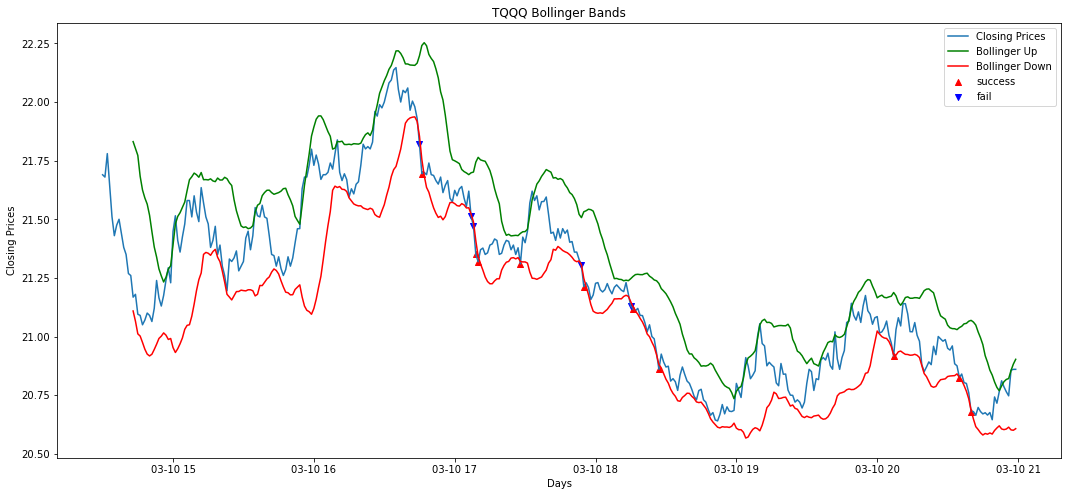

2023-03-13
8 8 1.0


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

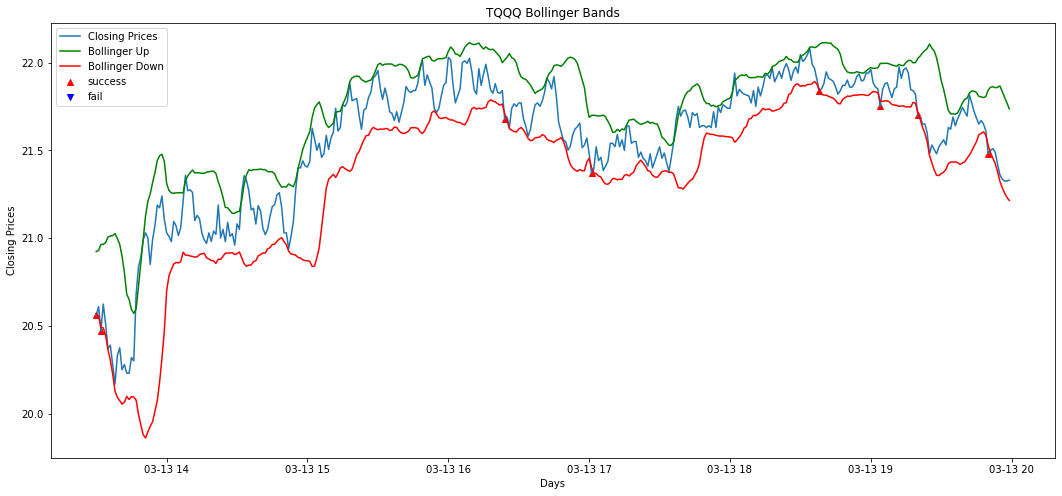

2023-03-14
15 13 0.8666666666666667


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

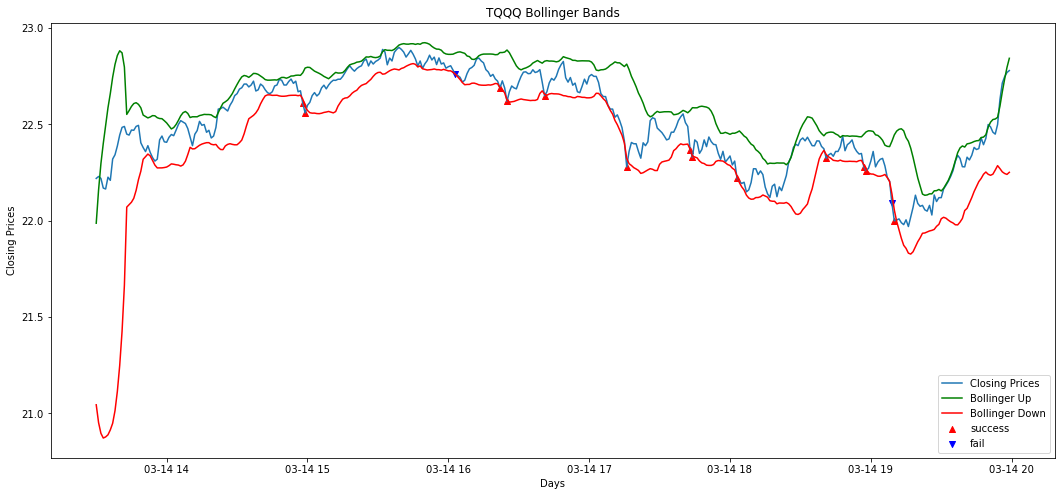

2023-03-15
15 13 0.8666666666666667


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

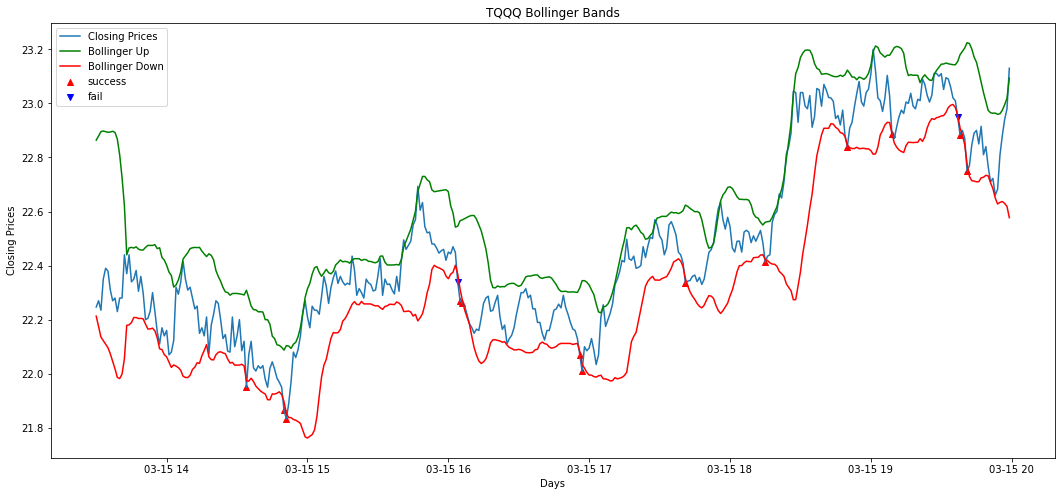

2023-03-16
8 8 1.0


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

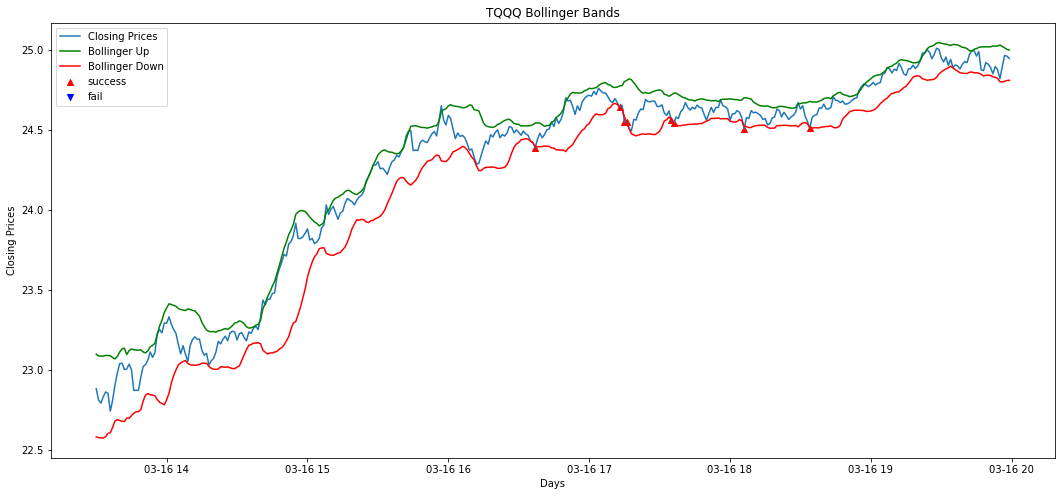

2023-03-17
16 15 0.9375


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

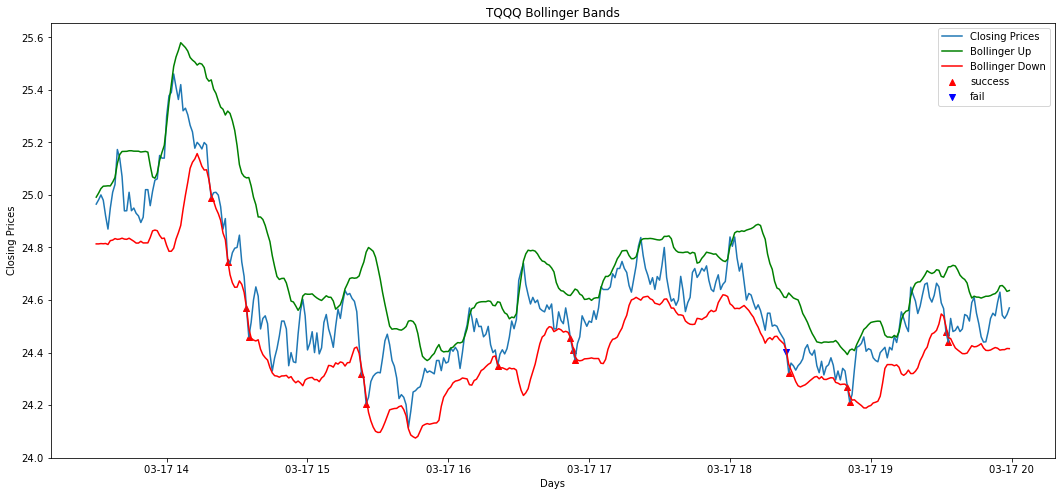

2023-03-20
13 10 0.7692307692307693


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

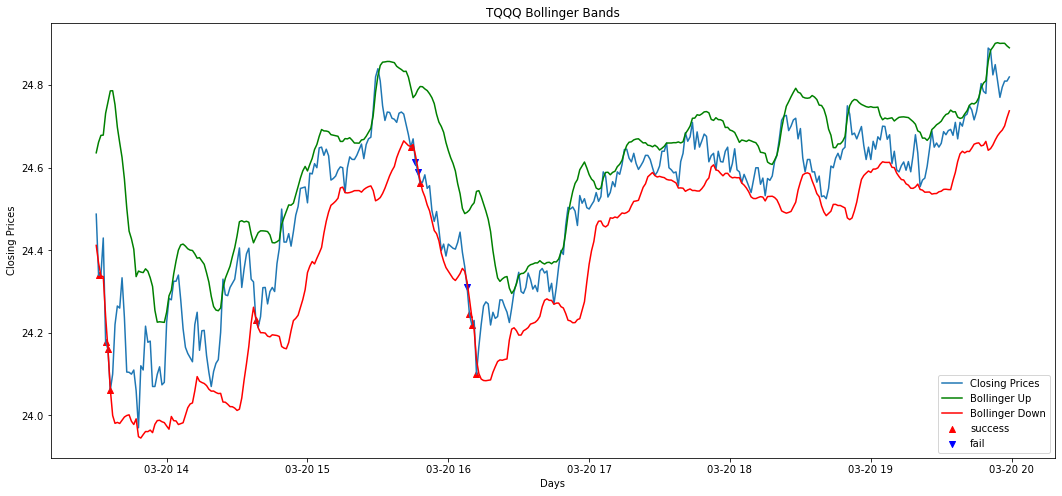

In [96]:
for i in np.unique(hist.index.date):
    print(i)
    daily_hist = hist[str(i):str(i)]

    plt.figure(figsize=(18,8))
    plt.title(symbol + ' Bollinger Bands')
    plt.xlabel('Days')
    plt.ylabel('Closing Prices')
    plt.plot(daily_hist['close'], label='Closing Prices')
    plt.plot(daily_hist['bollinger_up_14'], label='Bollinger Up', c='g')
    plt.plot(daily_hist['bollinger_down_14'], label='Bollinger Down', c='r')
#     plt.scatter(sub_hist[sub_hist['under_BBL']==1]['Close'].index, sub_hist[sub_hist['under_BBL']==1]['Close'],label='under bolligerband_low')

    # plt.plot(closing_prices, label='Closing Prices')
    # plt.plot(bollinger_up, label='Bollinger Up', c='g')
    # plt.plot(bollinger_down, label='Bollinger Down', c='r')

    
    
    for i in range(5):
        daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
    daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
    daily_hist['success'] = np.where((daily_hist['under_BBL'] == 1) & (daily_hist['close']*1.001 < daily_hist['highest']), 1,0)
    
    print(len(daily_hist[daily_hist['under_BBL']==1]), len(daily_hist[daily_hist['success']==1]), len(daily_hist[daily_hist['success']==1])/len(daily_hist[daily_hist['under_BBL']==1]))
    plt.scatter(daily_hist[daily_hist['success']==1]['close'].index, daily_hist[daily_hist['success']==1]['close'],label='success', marker = '^', color = 'r')
    plt.scatter(daily_hist[(daily_hist['success']==0) & (daily_hist['under_BBL']==1)]['close'].index, daily_hist[(daily_hist['success']==0) & (daily_hist['under_BBL']==1)]['close'],label='fail', marker = 'v', color = 'b')
    
    plt.legend()
    plt.show()

In [95]:
len(daily_hist[daily_hist['under_BBL']==1]) 

15